# コイン争奪戦 — クラス対戦演習

これまでの発展教材、クラス → 簡単なゲーム → バイナリとセキュリティ → ネットワークプログラミング の総まとめです。

教室のみなさんのPython botが、1つの盤面で同時に競います。

## ゲームのルール

- 24×24マスの盤面に コイン がいくつか出現します
- 各プレイヤーは、上下左右に1マスずつ動けます
- 他のプレイヤーがいるマスには入れません。ぶつかるとその場にとどまります
- コインの上に乗ると +1点。コインは別の場所に再出現します
- 制限時間で、得点が一番高い人の勝ち

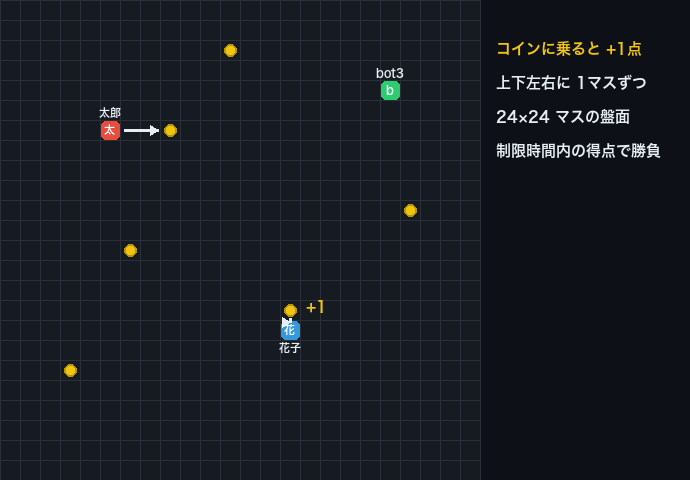

## 2つの役割

- 先生: 審判と盤面を兼ねるサーバを立て、公開URL を配る
- 生徒: サーバに接続する bot を書く。良い戦略を考えた人が勝つ

使う技術は全部これまでの復習です。ネットワーク回のHTTPクライアント/サーバ・JSON・botに加え、最後の🌶️の章ではバイナリ回のハッシュ／署名も出てきます。

---
# 共通: アリーナのコード

次の2つのセル、盤面の見た目とサーバ本体は、先生とソロ練習する生徒が実行します。アリーナを動かすための土台です。

まず下のセルで、盤面の見た目のHTMLを `board.html` に書き出します。`%%writefile` は、セルの中身をそのままファイルに保存する命令です。


In [ ]:
%%writefile board.html
<!doctype html>
<html>
<head>
  <meta charset="utf-8">
  <title>コイン争奪戦</title>
  <style>
    body { background: #0d1117; color: #e6edf3; font-family: sans-serif; text-align: center; margin: 0; }
    canvas { background: #161b22; border-radius: 8px; margin-top: 10px; }
    #rank { display: inline-block; text-align: left; margin: 8px auto; font-size: 15px; }
  </style>
</head>
<body>
  <h2>コイン争奪戦</h2>
  <canvas id="c" width="480" height="480"></canvas>
  <div id="rank"></div>
  <script>
    const cell = 20;
    const ctx = document.getElementById('c').getContext('2d');

    async function tick() {
      let s;
      try {
        s = await (await fetch('/state')).json();
      } catch (e) {
        return;
      }
      ctx.clearRect(0, 0, 480, 480);

      // 格子線
      ctx.strokeStyle = '#2a2f3a';
      ctx.lineWidth = 1;
      for (let i = 0; i <= 24; i++) {
        ctx.beginPath(); ctx.moveTo(i * cell, 0); ctx.lineTo(i * cell, 480); ctx.stroke();
        ctx.beginPath(); ctx.moveTo(0, i * cell); ctx.lineTo(480, i * cell); ctx.stroke();
      }

      ctx.textAlign = 'center';
      ctx.textBaseline = 'middle';

      // コイン
      ctx.font = '15px sans-serif';
      for (const c of s.coins) {
        ctx.fillText('🪙', c[0] * cell + cell / 2, c[1] * cell + cell / 2 + 1);
      }

      // プレイヤー: 色つきの角丸四角に、名前の1文字目
      for (const p of s.players) {
        const x = p.x * cell;
        const y = p.y * cell;
        ctx.fillStyle = p.color;
        ctx.beginPath();
        ctx.roundRect(x + 1, y + 1, cell - 2, cell - 2, 5);
        ctx.fill();
        const icon = Array.from(p.name)[0] || '?';
        ctx.fillStyle = '#fff';
        ctx.font = '13px sans-serif';
        ctx.fillText(icon, x + cell / 2, y + cell / 2 + 1);
        ctx.font = '10px sans-serif';
        ctx.fillText(p.name, x + cell / 2, y - 6);
      }

      // ランキング
      const r = [...s.players].sort((a, b) => b.score - a.score);
      document.getElementById('rank').innerHTML = '<b>ランキング</b><br>' +
        r.map((p, i) => `${i + 1}. <span style="color:${p.color}">■</span> ${p.name}: ${p.score}`).join('<br>');
    }

    setInterval(tick, 150);
  </script>
</body>
</html>


次がサーバ本体です。ネットワーク回で学んだ `http.server` の応用なので、興味があれば読んでみてください。

In [ ]:
# === アリーナサーバ ===
# ※ 先に「board.html を書き出すセル」を実行しておくこと
import json, threading, time, random
from http.server import BaseHTTPRequestHandler, ThreadingHTTPServer

W, H, NUM_COINS = 24, 24, 6

def _rand_pos():
    return [random.randint(0, W-1), random.randint(0, H-1)]

class ArenaServer(ThreadingHTTPServer):
    """プレイヤーとコインの状態を、このサーバ自身が持つ。
       本番とソロ練習のサーバは状態を共有しない。"""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.lock = threading.Lock()
        self.players = {}
        self.coins = [_rand_pos() for _ in range(NUM_COINS)]
        self.next_id = 0
    def reset(self):
        with self.lock:
            self.players = {}
            self.coins = [_rand_pos() for _ in range(NUM_COINS)]
            self.next_id = 0

class Arena(BaseHTTPRequestHandler):
    def _send(self, obj, code=200):
        body = json.dumps(obj).encode()
        self.send_response(code)
        self.send_header("Content-Type", "application/json; charset=utf-8")
        self.send_header("Access-Control-Allow-Origin", "*")   # どこからでも接続可
        self.end_headers()
        self.wfile.write(body)
    def _body(self):
        length = int(self.headers.get("Content-Length", 0))
        raw = self.rfile.read(length)
        return json.loads(raw or b"{}")

    def do_GET(self):
        srv = self.server
        if self.path == "/" or self.path.startswith("/?"):
            with open("board.html", encoding="utf-8") as f:
                body = f.read().encode()
            self.send_response(200)
            self.send_header("Content-Type", "text/html; charset=utf-8")
            self.end_headers()
            self.wfile.write(body)
        elif self.path == "/state":
            with srv.lock:
                self._send({"w": W, "h": H, "coins": srv.coins,
                    "players": [{"id": pid, "name": player["name"], "x": player["x"], "y": player["y"],
                                 "score": player["score"], "color": player["color"]} for pid, player in srv.players.items()]})
        else:
            self._send({"error": "not found"}, 404)

    def do_POST(self):
        srv = self.server
        data = self._body()
        if self.path == "/join":
            with srv.lock:
                pid = srv.next_id
                srv.next_id += 1
                pos = _rand_pos()
                name = str(data.get("name", "noname"))[:12]
                srv.players[pid] = {"name": name, "x": pos[0], "y": pos[1],
                                  "score": 0, "color": random.choice(["#e74c3c", "#3498db", "#2ecc71", "#e67e22", "#9b59b6", "#1abc9c", "#f39c12", "#fd79a8"])}
                self._send({"id": pid, "w": W, "h": H})
        elif self.path == "/move":
            with srv.lock:
                pid = data.get("id")
                player = srv.players.get(pid)
                if not player:
                    self._send({"error": "unknown id"}, 400)
                    return
                direction = data.get("dir")
                dx, dy = {"up": (0,-1), "down": (0,1), "left": (-1,0), "right": (1,0)}.get(direction, (0,0))
                new_x = player["x"] + dx
                new_y = player["y"] + dy
                if new_x < 0: new_x = 0
                if new_x > W - 1: new_x = W - 1
                if new_y < 0: new_y = 0
                if new_y > H - 1: new_y = H - 1
                # 他のプレイヤーがいるマスには入れない。移動をキャンセルする
                for other_id, other in srv.players.items():
                    if other_id != pid and other["x"] == new_x and other["y"] == new_y:
                        new_x, new_y = player["x"], player["y"]
                player["x"] = new_x
                player["y"] = new_y
                for coin in srv.coins:
                    if coin[0] == player["x"] and coin[1] == player["y"]:
                        player["score"] += 1
                        coin[0], coin[1] = _rand_pos()
                self._send({"x": player["x"], "y": player["y"], "score": player["score"]})
        elif self.path == "/reset":
            srv.reset()
            self._send({"ok": True})
        else:
            self._send({"error": "not found"}, 404)

    def log_message(self, *args):
        pass

def start_server():
    srv = ArenaServer(("0.0.0.0", 0), Arena)
    threading.Thread(target=srv.serve_forever, daemon=True).start()
    time.sleep(0.3)
    return srv, srv.server_address[1]

print("アリーナの準備OK。start_server() で起動できます。")

---
# 生徒セクション

各自のColabで、サーバに接続する bot を作ります。

## APIの仕様

| やりたいこと | 呼び出し | 返り値 |
|---|---|---|
| 参加する | `POST /join` `{"name": "名前"}` | `{"id": 自分の番号, "w":24, "h":24}` |
| 今の盤面を見る | `GET /state` | `{"coins": [[x,y]...], "players": [{"id","name","x","y","score","color"}...]}` |
| 動く | `POST /move` `{"id": 自分の番号, "dir": 向き}` | `{"x","y","score"}` |

- 向き `dir` は `"up"` / `"down"` / `"left"` / `"right"`
- 座標は左上が 0,0 で、x は右方向、y は下方向

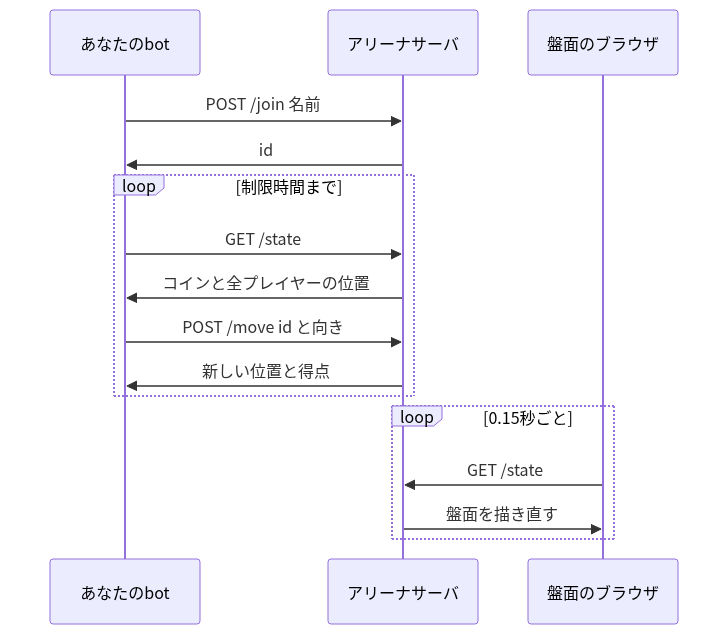


## 接続設定

サーバとのやり取りは、ネットワーク回で習った `requests` で行います。使う API は3つだけです。

- 参加する: `requests.post(SERVER + "/join", json={"name": 名前}).json()`
- 盤面を見る: `requests.get(SERVER + "/state").json()`
- 動く: `requests.post(SERVER + "/move", json={"id": 自分のid, "dir": 向き}).json()`

まず接続先の変数 `SERVER` を用意します。

In [ ]:
import requests

# 接続先。この後の「ローカルで練習」のセルで自動的に設定されます。
SERVER = ""

## まずローカルで練習する

先生の公開URLにつなぐ前に、自分のColabの中にアリーナを立てて練習します。下のセルを実行すると、接続先 `SERVER` が自分のローカルサーバに変わります。

In [ ]:
# ソロ練習の準備：サーバを立てる
# 先に「board.html」「アリーナサーバ」「接続設定」のセルを実行しておくこと
import time, requests

srv_local, solo_port = start_server()
SERVER = "http://127.0.0.1:%d" % solo_port   # 接続先を自分のローカルサーバに切り替え
print("ローカルのアリーナ:", SERVER)

# Colab のノート内に盤面を表示
try:
    from google.colab.output import serve_kernel_port_as_iframe
    serve_kernel_port_as_iframe(solo_port, path="/")
except Exception:
    pass

## join：ゲームに参加する

サーバに参加すると、自分の `id` がもらえます。これから、この id で「自分」を指定します。名前の1文字目が盤面のアイコンになるので、好きな絵文字を先頭に付けると自分のコマが見つけやすくなります。まず例題を実行し、次の演習を自分で書きましょう。

In [ ]:
# 例題：参加して、自分の id をもらう
me = requests.post(SERVER + "/join", json={"name": "テスト"}).json()
print(me)                 # 例: {'id': 0, 'w': 24, 'h': 24}
my_id = me["id"]
print("あなたの id:", my_id)

In [ ]:
# 演習：好きな名前で参加して、自分の id を表示しよう。名前の1文字目がアイコンになるので、絵文字もおすすめ



## state：今の盤面を見る

`GET /state` で、コインの位置と全プレイヤーの状態が返ります。

- `state["coins"]` … `[[x, y], ...]`
- `state["players"]` … `[{"id","name","x","y","score","color"}, ...]`

In [ ]:
# 例題：今の盤面を取得して中身を見る
state = requests.get(SERVER + "/state").json()
print("コインの数:", len(state["coins"]))
print("プレイヤー:", state["players"])

In [ ]:
# 演習：state を取得して、今この盤面に何人プレイヤーがいるか表示しよう



## move：動く

自分の `id` と向きを送ると、その方向へ1歩動きます。向きは `"up"` / `"down"` / `"left"` / `"right"` です。コインに乗ると得点です。他のプレイヤーがいるマスには入れず、その場にとどまります。

In [ ]:
# 例題：右に1歩動く
result = requests.post(SERVER + "/move", json={"id": my_id, "dir": "right"}).json()
print(result)             # 例: {'x': 11, 'y': 5, 'score': 0}

In [ ]:
# 演習：for ループで、好きな向きに5歩動かしてみよう



## botを作る

join / state / move を組み合わせると、自動で動く bot になります。いきなり全部は大変なので、部品を2つ練習してから、最後に while のくり返しにまとめます。

### 部品1：一番近いコインを探す

盤面のコインの中から、自分に一番近いものを選びます。for で1つずつ距離を見て、最小のものを覚えます。距離は `abs(x差) + abs(y差)`。

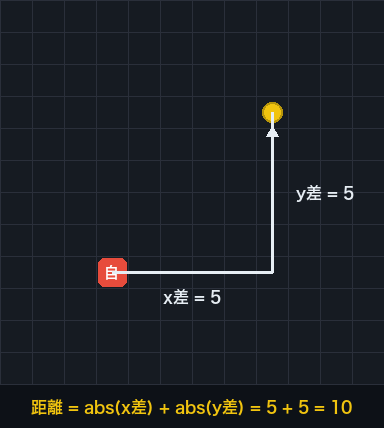


In [ ]:
# 参加して今の盤面を取得し、自分を探すところまで用意しています
me = requests.post(SERVER + "/join", json={"name": "あなた"}).json()
my_id = me["id"]
state = requests.get(SERVER + "/state").json()

me_now = None
for p in state["players"]:
    if p["id"] == my_id:
        me_now = p

# 演習：state["coins"] の中から、me_now に一番近いコインを探して best に入れて表示しよう


print("一番近いコイン:", best)

### 部品2：向きを決める

目標のコインの位置と自分の位置を比べて、動く向きを決めます。

In [ ]:
# 例として、自分の位置とコインの位置を置いておきます
mx, my = 10, 10
cx, cy = 15, 8

# 演習：(mx, my) から (cx, cy) へ向かう向きを direction に入れて表示しよう


print("向き:", direction)

### まとめ：botにする

部品1と部品2を、while のくり返しの中に組み込みます。下の骨組みの空いている2か所に、上で書いたコードを入れて完成させましょう。15秒間プレイします。

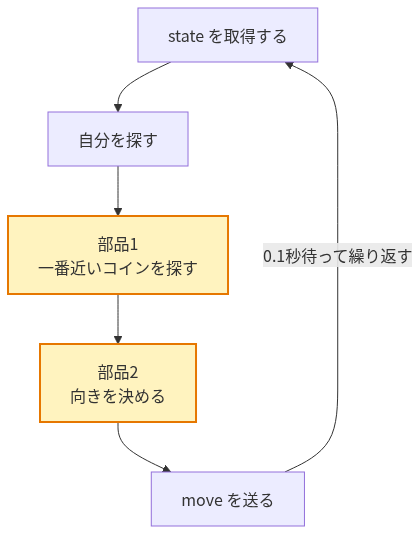


In [ ]:
import time

me = requests.post(SERVER + "/join", json={"name": "あなた"}).json()
my_id = me["id"]

end = time.time() + 15
while time.time() < end:
    state = requests.get(SERVER + "/state").json()

    me_now = None
    for p in state["players"]:
        if p["id"] == my_id:
            me_now = p

    # ここに「部品1：一番近いコインを探す」を書く → best に入れる


    # ここに「部品2：向きを決める」を書く → direction に入れる


    requests.post(SERVER + "/move", json={"id": my_id, "dir": direction})
    time.sleep(0.1)

# 得点を表示
score = 0
for p in requests.get(SERVER + "/state").json()["players"]:
    if p["id"] == my_id:
        score = p["score"]
print("15秒プレイ終了。得点:", score)

## botを強くする

上で作ったbotをコピーして、自分なりに強くしてみましょう。たとえば:

- 他プレイヤーがすぐ近くにいるコインは避ける。`state["players"]` で他プレイヤーの位置が分かります
- コインが密集している方を狙う

くり返しの中の「向きを決める部分」を工夫します。

In [ ]:
# 上の例題をコピーして、向きの決め方を工夫しよう



## 対戦相手のダミー敵を出す

自分のbotができたら、対戦相手を用意しましょう。下のセルは、ランダムに動くだけの敵を3体、`threading` で同時に動かします。実行してから自分のbotをもう一度動かすと、対戦になります。

In [ ]:
import threading, time, random, requests

# ランダムに動くだけの敵
def dummy(name):
    me = requests.post(SERVER + "/join", json={"name": name}).json()
    my_id = me["id"]
    while True:
        direction = random.choice(["up", "down", "left", "right"])
        requests.post(SERVER + "/move", json={"id": my_id, "dir": direction})
        time.sleep(0.15)

for enemy_name in ["敵A", "敵B", "敵C"]:
    threading.Thread(target=dummy, args=(enemy_name,), daemon=True).start()
print("ダミーの敵を3体 動かしました。")

---
# 本番：クラス対戦

完成した自分のbotで、先生の公開URLにつないで全員と競います。先生がサーバを立てて公開URLを配り、生徒は接続先をそのURLに変えてbotを走らせます。

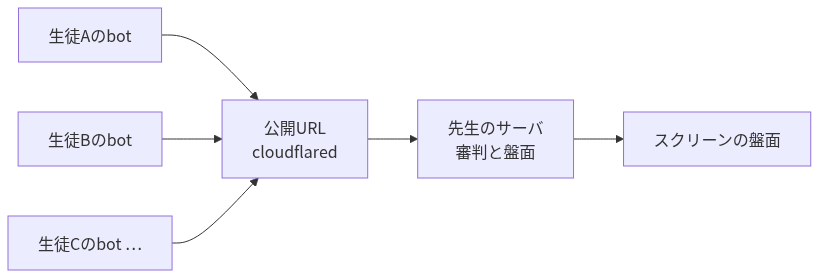

## 先生: サーバを起動する


In [ ]:
# 【先生】サーバを起動する
server, PORT = start_server()
print("サーバ起動 ポート:", PORT)

## 先生: 公開URLを発行する

`cloudflared` で、教室の全員が接続できる `https://xxxx.trycloudflare.com` の形の公開URLを発行し、生徒に伝えます。


In [ ]:
# cloudflared で公開URLを発行
# ※ ネットワーク環境によっては使えないことがあります。その場合は「ソロ練習」で開発を。
import os, re, subprocess, urllib.request

if not os.path.exists("cloudflared"):
    print("cloudflared をダウンロード中...")
    urllib.request.urlretrieve(
        "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64",
        "cloudflared")
    os.chmod("cloudflared", 0o755)

proc = subprocess.Popen(["./cloudflared", "tunnel", "--url", "http://localhost:%d" % PORT],
                        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
public_url = None
for line in proc.stdout:                      # 出力から公開URLを拾う
    match = re.search(r"https://[-a-z0-9]+\.trycloudflare\.com", line)
    if match:
        public_url = match.group(0)
        break
print("=" * 50)
print("公開URL:", public_url)
print("=" * 50)

## 先生: ラウンドをリセットする

対戦を仕切り直すときに実行します。全員の得点と位置を消して、新しいコインを配置します。


In [ ]:
# 【先生】ラウンドをリセット
import requests
reset_url = "http://127.0.0.1:{}/reset".format(PORT)
requests.post(reset_url)
print("アリーナをリセットしました")

## 生徒: 本番に接続する

下のセルで接続先を先生の公開URLに変えてから、自分のbotのセルをもう一度実行しましょう。


In [ ]:
# 本番：先生の公開URLに変えて、自分のbotで参加する
SERVER = "https://ここに先生のURL.trycloudflare.com"

# SERVER を変えたら、上で作った自分のbotのセルをもう一度実行すると本番に参加できます。
# 対戦時間に合わせて、bot の中の end = time.time() + 15 の 15 を長くしてもOKです。
print("接続先を本番に変えました。自分のbotのセルを実行しましょう。")

---
# 🌶️ Gradio の操作パネルで人間プレイヤーとして参加する

これまでプレイヤーは bot でした。前回学んだ Gradio で 操作パネル を作れば、人間がボタンで参加して、みんなのbotに混じって遊べます。

仕組みは数当ての公開と同じ「Gradio ← `requests` → アリーナサーバ」。ボタンを押すと `/move` をサーバへ送り、`/state` を取り直して盤面を絵にして表示します。

- 盤面を絵に描く `render()` は `PIL` で用意してあります
- あなたが書くのは、ボタンが押されたときに サーバへ動きを送る 1行です

先に「接続設定」の `SERVER` と、対戦相手のサーバ、つまり先生の公開URLかソロ練習を用意しておいてください。

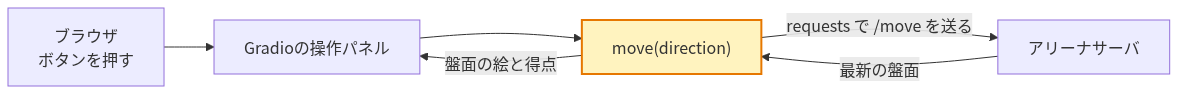


In [ ]:
!pip install --quiet gradio

In [ ]:
import gradio as gr
import requests
from PIL import Image, ImageDraw

CELL = 16   # 1マスの大きさ。ピクセル単位

def render(state):
    """盤面の状態を絵にする"""
    W, H = state["w"], state["h"]
    img = Image.new("RGB", (W * CELL, H * CELL), "#161b22")
    draw = ImageDraw.Draw(img)
    for i in range(W + 1):                             # 格子線
        draw.line([(i*CELL, 0), (i*CELL, H*CELL)], fill="#2a2f3a")
    for j in range(H + 1):
        draw.line([(0, j*CELL), (W*CELL, j*CELL)], fill="#2a2f3a")
    for x, y in state["coins"]:                        # コイン: 黄色の輪
        draw.ellipse([x*CELL+3, y*CELL+3, x*CELL+CELL-3, y*CELL+CELL-3], outline="#f1c40f", width=3)
    for p in state["players"]:                         # プレイヤー: 色つきの四角
        x, y = p["x"], p["y"]
        draw.rounded_rectangle([x*CELL+2, y*CELL+2, x*CELL+CELL-2, y*CELL+CELL-2], radius=4, fill=p["color"])
    return img

my_id = None

def join_game(name):
    global my_id
    my_id = requests.post(SERVER + "/join", json={"name": name}).json()["id"]   # 参加して自分のidをもらう
    state = requests.get(SERVER + "/state").json()
    return render(state), "参加しました。id={}".format(my_id)

def move(direction):
    if my_id is None:
        return None, "先に「参加する」を押してください"

    # ここで、direction 方向への /move を requests で SERVER に送る


    state = requests.get(SERVER + "/state").json()     # 最新の盤面を取り直す
    me = next((p for p in state["players"] if p["id"] == my_id), None)
    return render(state), "あなたのスコア: {}".format(me["score"] if me else 0)

# --- 操作パネルの見た目 ---
with gr.Blocks() as demo:
    gr.Markdown("## アリーナ操作パネル")
    name_in = gr.Textbox(label="名前", value="人間")
    join_btn = gr.Button("参加する", variant="primary")
    board = gr.Image(label="盤面")
    info = gr.Textbox(label="状態")
    up = gr.Button("↑ 上")
    with gr.Row():
        left = gr.Button("← 左")
        down = gr.Button("↓ 下")
        right = gr.Button("→ 右")

    join_btn.click(join_game, inputs=name_in, outputs=[board, info])
    up.click(lambda: move("up"),       outputs=[board, info])
    down.click(lambda: move("down"),   outputs=[board, info])
    left.click(lambda: move("left"),   outputs=[board, info])
    right.click(lambda: move("right"), outputs=[board, info])

demo.launch(share=True)

---
# チートとその対策

今のアリーナには「本人確認」がありません。`id` を知っていれば誰でも他人を動かせます。ここからは対策を1つずつ積み上げていきます。攻撃を試す → 守りを足す → その守りの穴を突く → さらに守りを足す、の繰り返しです。

## 攻撃：なりすまし移動

`id` さえ分かれば、他人になりすまして動かせてしまいます。試しに `id=0` のプレイヤーを勝手に動かしてみます。

In [ ]:
# 演習：id=0 の他人を勝手に動かしてみよう
#   SERVER + "/move" に {"id": 0, "dir": 好きな向き} を送り、返ってくるJSONを表示する
#   本人確認が無いので、他人の move が通ってしまうはず


## 対策の1歩目：共通鍵で本人確認する

サーバが `join` のとき、プレイヤーごとに、本人とサーバだけが知る合言葉、共通鍵 を発行して渡します。`move` には共通鍵を添えて送り、サーバは覚えている鍵と一致するかを確かめます。鍵を知らない人の `move` は拒否され、403 が返ります。

まずこの仕組みだけを入れたサーバを起動します。

In [ ]:
# 共通鍵で本人確認するサーバ
import json, threading, time, random, requests
from http.server import BaseHTTPRequestHandler, ThreadingHTTPServer

class KeyServer(ThreadingHTTPServer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.keys = {}       # id -> 共通鍵
        self.next_id = 0

class KeyHandler(BaseHTTPRequestHandler):
    def _send(self, obj, code=200):
        body = json.dumps(obj).encode()
        self.send_response(code)
        self.send_header("Content-Type", "application/json")
        self.end_headers()
        self.wfile.write(body)
    def _body(self):
        length = int(self.headers.get("Content-Length", 0))
        raw = self.rfile.read(length)
        return json.loads(raw or b"{}")
    def do_POST(self):
        srv = self.server
        data = self._body()
        if self.path == "/join":
            pid = srv.next_id
            srv.next_id += 1
            key = str(random.randint(10000000, 99999999))   # 8桁の数を共通鍵として発行
            srv.keys[pid] = key
            self._send({"id": pid, "key": key})
        elif self.path == "/move":
            pid = data.get("id")
            if srv.keys.get(pid) is None:
                self._send({"error": "unknown id"}, 400)
                return
            if data.get("key") != srv.keys[pid]:                  # 鍵が一致するか確認
                self._send({"error": "bad key"}, 403)
                return
            self._send({"ok": True})
        else:
            self._send({"error": "not found"}, 404)
    def log_message(self, *args):
        pass

_ks = KeyServer(("127.0.0.1", 0), KeyHandler)
threading.Thread(target=_ks.serve_forever, daemon=True).start()
time.sleep(0.3)
AUTH = "http://127.0.0.1:%d" % _ks.server_address[1]
print("共通鍵サーバ:", AUTH)

In [ ]:
# 演習：参加して共通鍵をもらい、鍵を添えて動こう
# 1) AUTH + "/join" に参加して、返ってきた id を pid に、共通鍵を key に入れる
# 2) AUTH + "/move" に id・向き・鍵 の3つを入れた辞書を送り、結果を表示する
#    {'ok': True} が返れば成功


In [ ]:
# 演習：わざと間違った鍵で move を送り、結果コードが 403 になることを確かめよう
#   requests.post(...).status_code で結果コードが取れます

## 攻撃：盗聴で共通鍵が盗まれる

本人確認はできましたが、大きな穴があります。`move` のたびに共通鍵をそのまま送っているので、通信を覗いた攻撃者には鍵が丸見えです。盗んだ鍵を使えば、なりすましは簡単です。

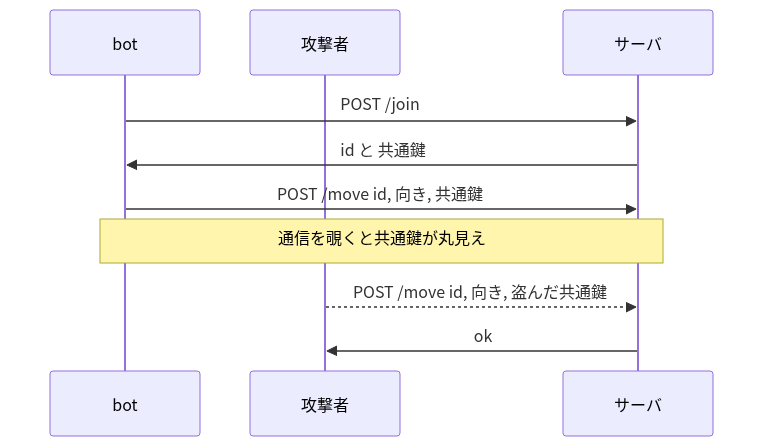


In [ ]:
# 通信には毎回こういうJSONが流れている。覗けば key が丸見え
print({"id": pid, "dir": "up", "key": key})

# 演習：攻撃者になって、盗んだ鍵 stolen でプレイヤー pid を勝手に動かしてみよう
#   {'ok': True} が返ってしまい、この方式が盗聴に弱いことを確かめる
stolen = key       # 通信を覗いて鍵を手に入れた、ということにする


## 対策の2歩目：鍵は送らず、ハッシュで署名する

共通鍵そのものは二度と送りません。かわりに「共通鍵＋動きの内容」をつないだ文字列の ハッシュ を計算し、署名 として送ります。サーバは自分が覚えている鍵で同じ計算をして照合します。

- なりすまし防止: 攻撃者は鍵を知らないので、正しい署名を作れない
- 改ざん検知: 動きの内容が1文字でも変われば署名も変わる

この仕組みに変えたサーバを起動します。

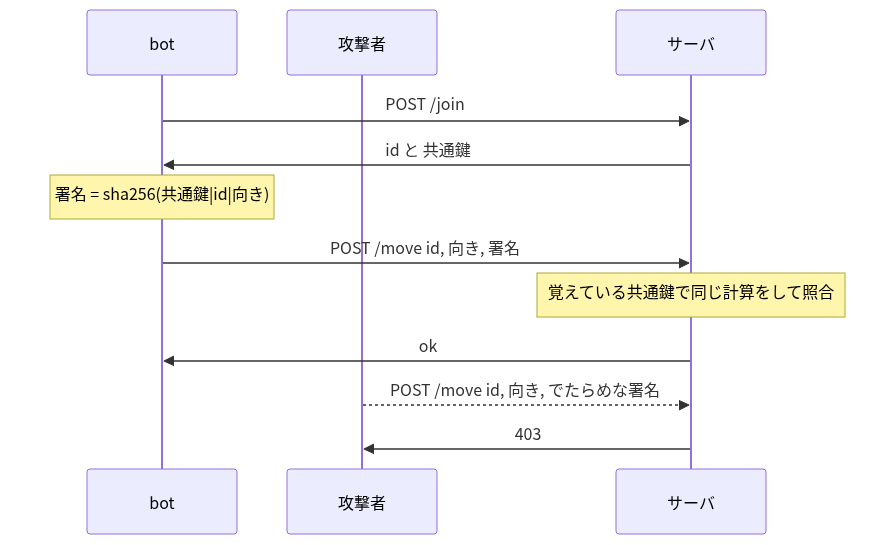


In [ ]:
# 署名つきの実験サーバ
import json, threading, time, random, hashlib, requests
from http.server import BaseHTTPRequestHandler, ThreadingHTTPServer

class SecureServer(ThreadingHTTPServer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.keys = {}       # id -> 共通鍵
        self.next_id = 0

class SecureHandler(BaseHTTPRequestHandler):
    def _send(self, obj, code=200):
        body = json.dumps(obj).encode()
        self.send_response(code)
        self.send_header("Content-Type", "application/json")
        self.end_headers()
        self.wfile.write(body)
    def _body(self):
        length = int(self.headers.get("Content-Length", 0))
        raw = self.rfile.read(length)
        return json.loads(raw or b"{}")
    def do_POST(self):
        srv = self.server
        data = self._body()
        if self.path == "/join":
            pid = srv.next_id
            srv.next_id += 1
            key = str(random.randint(10000000, 99999999))   # 8桁の数を共通鍵として発行
            srv.keys[pid] = key
            self._send({"id": pid, "key": key})
        elif self.path == "/move":
            pid = data.get("id")
            key = srv.keys.get(pid)
            if key is None:
                self._send({"error": "unknown id"}, 400)
                return
            # 署名の照合。共通鍵は送られてこないので、クライアントと同じ計算をして比べる
            direction = data.get("dir")
            message = f"{key}|{pid}|{direction}"
            message_bytes = message.encode()
            want = hashlib.sha256(message_bytes).hexdigest()
            if data.get("sig") != want:
                self._send({"error": "bad signature"}, 403)
                return
            self._send({"ok": True})
        else:
            self._send({"error": "not found"}, 404)
    def log_message(self, *args):
        pass

_ss = SecureServer(("127.0.0.1", 0), SecureHandler)
threading.Thread(target=_ss.serve_forever, daemon=True).start()
time.sleep(0.3)
SECURE = "http://127.0.0.1:%d" % _ss.server_address[1]
print("署名つきサーバ:", SECURE)

## 署名つきで動く

参加して共通鍵をもらい、move ごとに `sha256(共通鍵|id|向き)` の署名を付けて送ります。今度は通信に流れるのは署名だけで、鍵は流れません。署名を作る部分を書きましょう。

In [ ]:
import hashlib

me = requests.post(SECURE + "/join", json={}).json()
pid = me["id"]
key = me["key"]

direction = "up"

# 演習：署名 sig を作ろう
#   1) message = f"{key}|{pid}|{direction}" の文字列を作る
#   2) message を .encode() でバイト列にする
#   3) その sha256 の16進文字列を .hexdigest() で取り出して sig に入れる


res = requests.post(SECURE + "/move", json={"id": pid, "dir": direction, "sig": sig}).json()
print(res)

## なりすましは弾かれる

通信を覗いても流れているのは署名だけです。ハッシュは不可逆なので署名から鍵は逆算できず、鍵が無いと新しい署名は作れません。でたらめな署名で送ると拒否され、403 が返ります。

In [ ]:
# 演習：共通鍵を知らない攻撃者になって、でたらめな署名で move を送ってみよう
#   sig に適当な文字列を入れて送り、結果コードが 403 になることを確かめる


## 盗聴対策：XOR暗号で通信を暗号化する

署名はなりすましと改ざんを防ぎますが、通信の中身、つまりどの向きに動いたかは覗けばそのまま読めます。中身も隠したいときは、セキュリティ回で学んだ 共通鍵での暗号化 を使います。ここでは一番シンプルな XOR暗号 を使います。

同じ鍵でもう一度XORすると元に戻る、という性質がポイントです。

In [ ]:
# 演習：セキュリティ回の xor_cipher をもう一度書いて、暗号化→復号を確かめよう
# 1) xor_cipher(data, key) を定義する。bytes の各バイトを key とXORして bytes で返す
def xor_cipher(data, key):
    pass

# 2) 共通鍵 0x5A で "up" を暗号化し、.hex() で暗号文を表示する
# 3) 暗号文にもう一度 xor_cipher をかけて、"up" に戻ることを確かめる


In [ ]:
# 演習：受け取った暗号文 secret を、共通鍵 key で復号して向きを取り出そう
#   上の xor_cipher がそのまま使えます
key = 0x5A
secret = bytes.fromhex("3e352d34")   # ある向きを暗号化したもの

# ここに復号して、文字列 direction を求めるコードを書く


print("隠されていた向き:", direction)

## 🌶️ RSA の公開鍵で署名する

共通鍵方式は「サーバと本人が同じ鍵を共有」します。公開鍵署名なら、bot が 秘密鍵 で署名し、サーバは 公開鍵 で検証するので、鍵を共有せずに本人確認できます。セキュリティ回の手作りRSAをそのまま使って、署名と検証を自分でやってみましょう。


In [ ]:
import hashlib

# セキュリティ回と同じ手作りRSAの鍵
p, q = 61, 53
N = p * q
e = 17
d = pow(e, -1, (p - 1) * (q - 1))     # 秘密鍵

# 署名したい内容と、そのダイジェスト。ハッシュを N 未満の数にしたもの
move = "up"
move_bytes = move.encode()
move_hash = hashlib.sha256(move_bytes).hexdigest()
digest = int(move_hash, 16) % N

# 演習：
# 1) 秘密鍵 d で digest に署名して signature を作る。セキュリティ回と同じく pow を使う
# 2) サーバ役になって、公開鍵 (e, N) で signature を検証し、digest と一致するか表示する


In [ ]:
# 演習：改ざんを検知しよう
#   攻撃者が move を "down" に書き換えたとする
# 1) 上の digest と同じ作り方で、"down" のダイジェスト tampered を作る
# 2) 上の signature を公開鍵 (e, N) で検証した結果が tampered と一致しないことを表示する
#    一致しなければ、改ざんが検知できたということ


## まとめ

- なりすまし → 共通鍵で本人確認する
- 盗聴で鍵が盗まれる → 鍵は送らず、ハッシュ署名にする
- 改ざん → 内容が変われば署名も変わるので検出できる
- 通信の中身も隠したい → XOR暗号
- 鍵の共有をなくしたい → RSAの公開鍵署名

「攻撃を知り、穴をひとつずつ塞ぐ」。これがセキュリティ設計の基本です。


## 総合演習：アリーナサーバをセキュリティ強化する

最初に使ったアリーナサーバは `/move` に `id` と `dir` を送るだけで、本人確認がありませんでした。ここまでの 共通鍵とハッシュ署名 を組み込んだ強化版サーバを用意しました。`/join` で共通鍵を配り、`/move` で署名を照合し、通れば盤上のコマを動かします。このセルは起動するだけです。

あなたの仕事は クライアント側 です。次の3つを確かめるコードを書いてください。

1. 正しく署名した move が通り、新しい位置 `pos` が返る
2. でたらめな署名によるなりすましが弾かれ、403 が返る
3. 署名はそのままで向きだけ書き換えた改ざんが弾かれ、403 が返る

In [ ]:
# 署名で本人確認する強化版アリーナサーバ
import json, threading, time, random, hashlib, requests
from http.server import BaseHTTPRequestHandler, ThreadingHTTPServer

class SecureArena(ThreadingHTTPServer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.keys = {}       # id -> 共通鍵
        self.pos = {}        # id -> [x, y]
        self.next_id = 0

def _sign(key, pid, direction):
    message = f"{key}|{pid}|{direction}"
    message_bytes = message.encode()
    return hashlib.sha256(message_bytes).hexdigest()

class SArenaHandler(BaseHTTPRequestHandler):
    def _send(self, obj, code=200):
        body = json.dumps(obj).encode()
        self.send_response(code)
        self.send_header("Content-Type", "application/json")
        self.end_headers()
        self.wfile.write(body)
    def _body(self):
        length = int(self.headers.get("Content-Length", 0))
        raw = self.rfile.read(length)
        return json.loads(raw or b"{}")
    def do_POST(self):
        srv = self.server
        data = self._body()
        if self.path == "/join":
            pid = srv.next_id
            srv.next_id += 1
            key = str(random.randint(10000000, 99999999))   # 8桁の数を共通鍵として発行
            srv.keys[pid] = key
            srv.pos[pid] = [12, 12]
            self._send({"id": pid, "key": key, "pos": srv.pos[pid]})
        elif self.path == "/move":
            pid = data.get("id")
            key = srv.keys.get(pid)
            if key is None:
                self._send({"error": "unknown id"}, 400)
                return
            direction = data.get("dir")
            want = _sign(key, pid, direction)
            if data.get("sig") != want:
                self._send({"error": "bad signature"}, 403)
                return
            x, y = srv.pos[pid]
            dx = {"left": -1, "right": 1}.get(direction, 0)
            dy = {"up": -1, "down": 1}.get(direction, 0)
            new_x = x + dx
            new_y = y + dy
            if new_x < 0: new_x = 0
            if new_x > 23: new_x = 23
            if new_y < 0: new_y = 0
            if new_y > 23: new_y = 23
            srv.pos[pid] = [new_x, new_y]
            self._send({"ok": True, "pos": srv.pos[pid]})
        else:
            self._send({"error": "not found"}, 404)
    def log_message(self, *args):
        pass

_sa = SecureArena(("127.0.0.1", 0), SArenaHandler)
threading.Thread(target=_sa.serve_forever, daemon=True).start()
time.sleep(0.3)
ARENA2 = "http://127.0.0.1:%d" % _sa.server_address[1]
print("強化版アリーナ:", ARENA2)

In [ ]:
import hashlib

# 総合演習：強化版アリーナ(ARENA2)に参加し、共通鍵で署名して安全に動こう
# 1) 参加して id と 共通鍵 key を受け取る
# 2) 署名を作る関数 sign(key, pid, direction) を用意する。sha256 の16進文字列を返す
# 3) 次の3つを確かめる
#    (a) 正しい署名の move が通り、ok と新しい pos が返る
#    (b) でたらめな署名によるなりすましが 403 になる
#    (c) 署名はそのまま dir だけ書き換えた改ざんが 403 になる

---
# おわりに

ここまでで、あなたは自分の手で サーバを立て、通信し、botを動かし、全員で競い、そして不正と対策まで 体験しました。

- クラスでデータの設計図を作り
- バイナリとセキュリティでデータの正体と守り方を知り
- ネットワークで通信の仕組みを作り
- そして今日、それらを 全部つないで 動くものを作りました

ここからは、ルールを変える・戦略を磨く・不正対策を実装する——好きに拡張してみてください。おつかれさまでした。